# Global Co2 Emissions Responsibility : Total vs Per-Capita vs Historical Accountability Dashboard

## Introduction
Brief overview of analysis purpose
This exploratory data analysis investigates global CO2 emissions responsibility using total emissions, per-capita emissions, and cumulative historical contributions. The purpose of this analysis is to understand how responsibility for climate change differs between countries when viewed from different perspectives.

The analysis focuses on data from 1990 onwards to align with international climate policy baselines. Insights generated from this stage will inform the design of the interactive dashboard and support clear communication of fairness, accountability, and long-term emissions trends.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')  


In [4]:
# Loading the dataset
df_co2_emissions_clean = pd.read_csv('../DataSet/Cleaned/CO2_Emissions_Cleaned.csv')
# Displaying the first few rows of the dataset
df_co2_emissions_clean.head()


,country,iso_code,year,co2,co2_per_capita,gdp,population,cumulative_co2
0,Afghanistan,AFG,1990,2.024326,0.168054,1.306598e+10,12045664.0,58.603493
1,Afghanistan,AFG,1991,1.914301,0.156411,1.204736e+10,12238879.0,60.517792
2,Afghanistan,AFG,1992,1.482054,0.111609,1.267754e+10,13278983.0,61.999847
3,Afghanistan,AFG,1993,1.486943,0.099506,9.834582e+09,14943175.0,63.486794
4,Afghanistan,AFG,1994,1.453829,0.089462,7.919856e+09,16250800.0,64.940620


In [25]:
## Descriptive statistics of the dataset
df_co2_emissions_clean.describe()

,year,co2,co2_per_capita,gdp,population,cumulative_co2
count,7508.000000,7508.000000,7442.000000,5.409000e+03,7.442000e+03,7508.000000
mean,2007.035828,137.544464,5.022831,4.895098e+11,3.179892e+07,5822.072674
std,10.083330,675.286457,7.795041,1.705000e+12,1.262322e+08,27988.146188
min,1990.000000,0.000000,0.000000,2.571720e+08,1.776000e+03,0.000000
25%,1998.000000,0.852971,0.714055,1.886576e+10,7.567225e+05,23.068187
50%,2007.000000,7.172069,2.744757,6.111433e+10,5.713997e+06,227.102509
75%,2016.000000,53.937630,6.832723,2.910000e+11,2.045923e+07,1978.472718
max,2024.000000,12289.037110,364.790833,2.700000e+13,1.450936e+09,434866.562500


In [35]:
##Dataset information
df_co2_emissions_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7508 entries, 0 to 7507
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         7508 non-null   object 
 1   iso_code        7508 non-null   object 
 2   year            7508 non-null   int64  
 3   co2             7508 non-null   float64
 4   co2_per_capita  7442 non-null   float64
 5   gdp             5409 non-null   float64
 6   population      7442 non-null   float64
 7   cumulative_co2  7508 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 469.4+ KB


In [72]:
# Checking duplicates in the dataset
duplicates = df_co2_emissions_clean.duplicated()    
print(f"Number of duplicate rows: {duplicates.sum()}")      

Number of duplicate rows: 0


## Hypothesis 1
Statement: Global Co2 emissions have increased significantly since 1990,the baseline year widely used in international climate agreements. 
Validation: This will be evaluated using a global emissions trend line to observe changes over time

This analysis examines whether global Co2 emissions have increased since 1990

In [73]:
# Validating the H1: "Global Co2 emissions have increased significantly since 1990."
global_trend = df_co2_emissions_clean.groupby('year', as_index=False)['co2'].sum()
global_trend.head()



,year,co2
0,1990,22184.273978
1,1991,22662.921003
2,1992,21966.606838
3,1993,22192.437121
4,1994,22389.768557


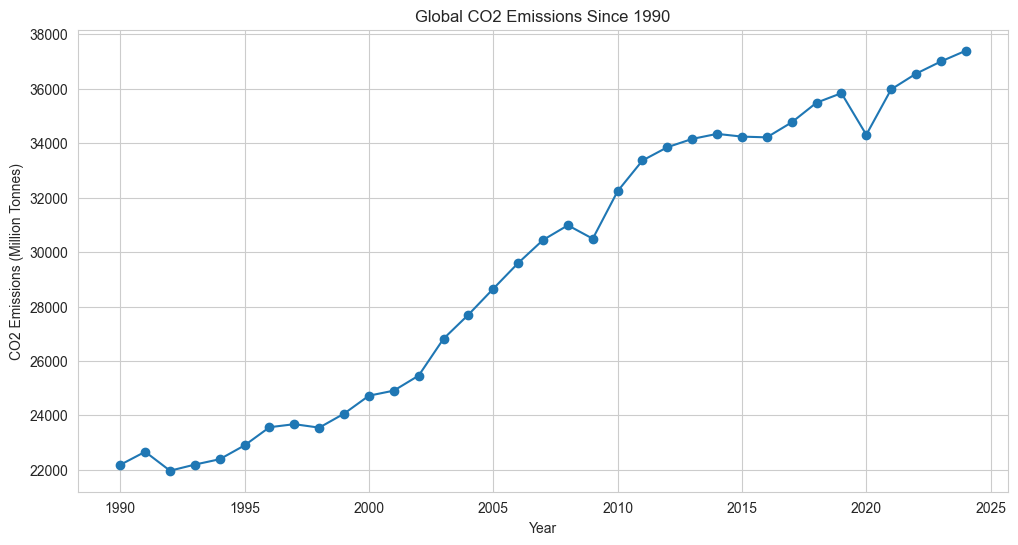

In [74]:
## Plotting the global CO₂ emissions trend over time
plt.figure(figsize=(12, 6))
plt.plot(global_trend['year'], global_trend['co2'], marker='o')
plt.title('Global CO2 Emissions Since 1990')
plt.xlabel('Year')
plt.ylabel('CO2 Emissions (Million Tonnes)')
plt.grid(True)
plt.show()

## Interpretation
The graph shows a clear upward trend in global Co2 emissions from 1990 to 2024. Emissions increased steadily throughout the 1990s and accelerated significantly during the early 2000s, reflecting rapid industrialisation and economic growth in emerging economies.

A period of slower growth  is visible between 2013 and 2016,where emissions appear to level off slightly before rising again, this could possibly be because of renewable adoption, efficiency improvements or economic slowdowns in some region. Followed by a sharp decline in 2020, likely linked to the global COVID-19 pandemic, reduced travel and reduced industrial activity. However, emissions rose quickly thereafter, reaching record highs by 2024.

Overall, the trend supports the hypothesis that global Co2 emissions have increased significantly since 1990.

## Hypothesis  H2: 
Statement : Countries with large populations account for higher total emissions but do not necessarily rank highest in per-capita emissions
Validation: This will be analysed using a total versus per-capita scatter plot divided into responsibility quadrants.
## Top Emitting Countries.
This section identifies the countries with the highest total CO₂ emissions in the most recent reporting year and checks whether high-population countries tend to dominate total emissions.


In [75]:
# Validating H2: "High population countries are the largest contributors to global CO₂ emissions."
## Finding the latest year in the dataset
latest_year = df_co2_emissions_clean['year'].max()
latest_year

2024

In [76]:
## Filtering the dataset for the latest year
df_latest_year = df_co2_emissions_clean[df_co2_emissions_clean['year'] == latest_year].copy()
df_latest_year.head()


,country,iso_code,year,co2,co2_per_capita,gdp,population,cumulative_co2
34,Afghanistan,AFG,2024,10.825998,0.253848,NaN,42647502.0,242.635437
69,Albania,ALB,2024,4.444448,1.591990,NaN,2791756.0,307.938110
104,Algeria,DZA,2024,198.203186,4.233817,NaN,46814302.0,5476.567871
139,Andorra,AND,2024,0.424663,5.181661,NaN,81955.0,16.654968
174,Angola,AGO,2024,22.333584,0.589497,NaN,37885854.0,739.587707


In [77]:
## dispaying the shape of the filtered dataset
df_latest_year.shape

(215, 8)

In [78]:
## Creating the top 10 countries by CO₂ emissions for the latest year
top10_countries = df_latest_year.sort_values(by='co2', ascending=False).head(10)


In [79]:
## creating the top 10 total emitters table
top10_countries_table = top10_countries[['country', 'co2', 'co2_per_capita', 'population']]
top10_countries_table

,country,co2,co2_per_capita,population
1469,China,12289.037110,8.658390,1.419321e+09
7192,United States,4904.119629,14.197287,3.454266e+08
3172,India,3193.478027,2.200978,1.450936e+09
5582,Russia,1780.524414,12.294705,1.448204e+08
3452,Japan,961.867310,7.772474,1.237530e+08
3207,Indonesia,812.220215,2.865096,2.834879e+08
3242,Iran,792.631165,8.656227,9.156774e+07
5897,Saudi Arabia,692.133484,20.379194,3.396275e+07
6317,South Korea,583.679138,11.285893,5.171759e+07
2682,Germany,572.319153,6.768824,8.455223e+07


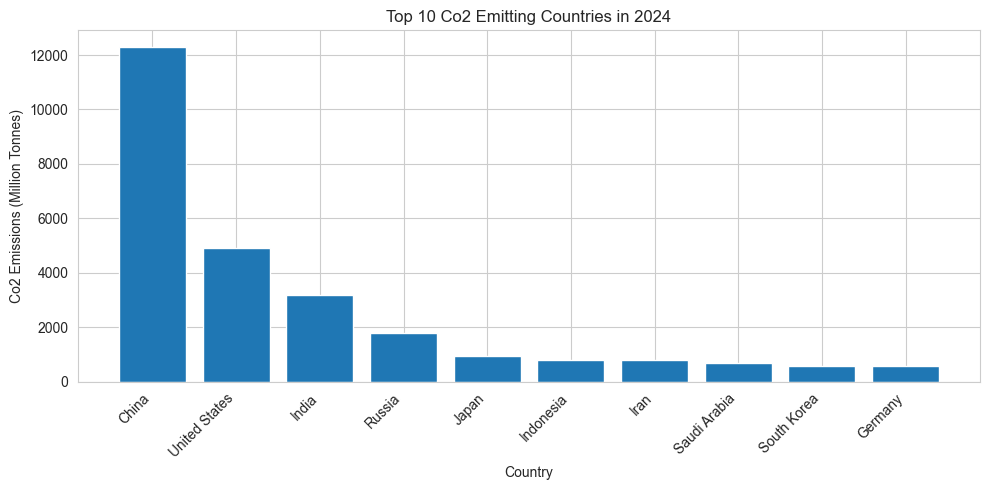

In [ ]:
## Creating a Bar Chart for the top 10 CO2 emitting countries
plt.figure(figsize=(10, 5))
plt.bar(top10_countries_table['country'], top10_countries_table['co2'])
plt.xlabel('Country')
plt.ylabel('Co2 Emissions (Million Tonnes)')
plt.title(f"Top 10 Co2 Emitting Countries in {latest_year}")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [81]:
## Validating if these top 10 countries are also the most populous
top10_countries.sort_values(by='population', ascending=False)[["country", "population", "co2"]]


,country,population,co2
3172,India,1.450936e+09,3193.478027
1469,China,1.419321e+09,12289.037110
7192,United States,3.454266e+08,4904.119629
3207,Indonesia,2.834879e+08,812.220215
5582,Russia,1.448204e+08,1780.524414
3452,Japan,1.237530e+08,961.867310
3242,Iran,9.156774e+07,792.631165
2682,Germany,8.455223e+07,572.319153
6317,South Korea,5.171759e+07,583.679138
5897,Saudi Arabia,3.396275e+07,692.133484



## Interpretation
The Top 10 chart shows that a small number of countries contribute a large share of total CO₂ emissions in 2024. China is the highest emitter by a wide margin, followed by the United States and India.

When population is considered, several countries in the Top 10 also have very large populations (for example China, India, the United States, and Indonesia). This suggests that population size is one important reason why some countries have high total emissions. However, population alone does not explain everything, because countries with similar population sizes can still have very different total emissions.

This supports the first part of H2: large-population countries often account for higher total emissions.

## H2 Part B Total Emissions  Vs Per Capita Emissions
This visual analysis examines whether countries with high total emissions also rank highly in per-capita emissions.

In [82]:
# Removing Missing Values from the latest year dataset
df_latest_year_clean = df_latest_year.dropna(subset=['co2', 'co2_per_capita']).copy()
df_latest_year_clean.shape


(213, 8)

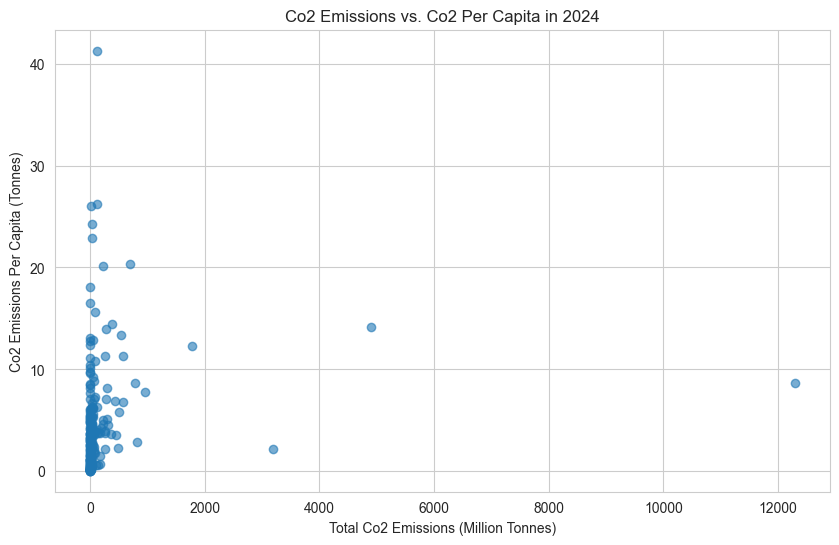

In [83]:
# Creating a scatter plot to visualize the relationship between population and CO₂ emissions for the latest year
plt.figure(figsize=(10, 6)) 
plt.scatter(df_latest_year_clean['co2'], df_latest_year_clean['co2_per_capita'], alpha=0.6)
plt.xlabel('Total Co2 Emissions (Million Tonnes)')
plt.ylabel('Co2 Emissions Per Capita (Tonnes)') 
plt.title(f'Co2 Emissions vs. Co2 Per Capita in {latest_year}')
plt.show()

## Interpretation
The scatter plot compares total CO₂ emissions with per-capita emissions for countries in 2024. Most countries are grouped in the lower-left area of the chart, showing that they have both low total emissions and low emissions per person, these countries are probably small economies, developing nations or low industrial output countries.

Highly populated countries such as China(12,000 total co2 emissions, < 10 per-capita) and India (3,000 total co2 emissions, 2 per-capita) appear far to the right of the chart, meaning they produce large amounts of total emissions. However, they sit lower on the per-capita scale, showing that their emissions per person are not among the highest. This indicates that large population size increases total emissions but does not automatically mean higher individual responsibility.

On the other hand, some countries such as Qatar, UAE, Kuwait,  with smaller populations appear higher on the per-capita axis even though their total emissions are lower. This shows that lifestyle, energy use, and industrial activity can lead to higher emissions per person.

Overall, the visual supports the hypothesis that countries with large populations produce higher total emissions but do not necessarily rank highest in per-capita 

## Hypothesis 3
Statement:  Developed countries tend to have higher CO₂ emissions per capita compared to developing countries.
Validation: This will be assessed through per-capita emission rankings and scatter plot comparisons.
This analysis examines whether developed countries tend to produce higher CO₂ emissions per person compared to developing countries.

In [84]:
# Per-Capits Ranking Table
top10_per_capita = df_latest_year_clean.dropna(subset=['co2_per_capita'])

# Sorting the dataset by co2_per_capita in descending order and selecting the top 10 countries      
top10_per_capita = top10_per_capita.sort_values(by='co2_per_capita', ascending=False).head(10)


In [85]:
# creating a table with only the country and co2_per_capita columns
top10_per_capita[['country', 'co2_per_capita']]

,country,co2_per_capita
5512,Qatar,41.271179
3627,Kuwait,26.247530
1084,Brunei,26.046202
559,Bahrain,24.270082
6842,Trinidad and Tobago,22.931944
5897,Saudi Arabia,20.379194
7122,United Arab Emirates,20.131075
4812,New Caledonia,18.064400
6107,Sint Maarten (Dutch part),16.546274
5127,Oman,15.651107


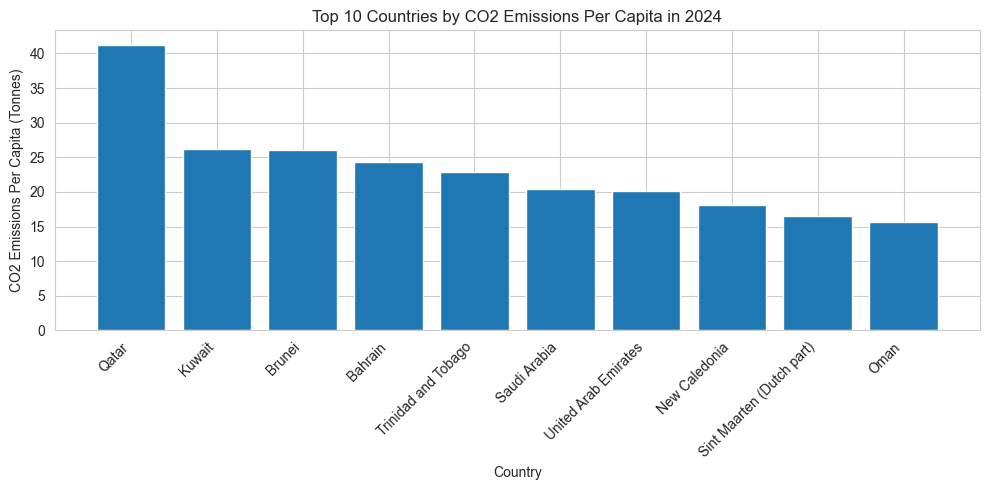

In [86]:
# Plotting a bar chart for the top 10 countries by Co2 emissions per capita
plt.figure(figsize=(10, 5))
plt.bar(top10_per_capita['country'], top10_per_capita['co2_per_capita'])
plt.xlabel('Country')
plt.ylabel('CO2 Emissions Per Capita (Tonnes)')
plt.title(f'Top 10 Countries by CO2 Emissions Per Capita in {latest_year}')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Interpretation
The bar chart shows the countries with the highest CO₂ emissions per capita in 2024. Qatar ranks significantly higher than all other countries, followed by Kuwait, Brunei, and Bahrain.
Most of the countries in the Top 10 are high-income or oil-producing economies. Their energy-intensive industries and high consumption levels contribute to elevated emissions per person. Despite having smaller populations, these countries produce much higher emissions per individual.Their responsibility is industry driven rather than population driven.
In contrast, many developing countries with large populations such as India, Indonesia, Nigeria do not appear in the per-capita Top 10. This highlights the difference between total emissions and individual emissions responsibility.
Overall, this support the hypothesis that developed countries tend to have higher CO₂ emissions per capita compared to developing countries.

## Hypothesis 4
Statement: Countries with the highest historical cumulative emissions are not always the same as those with the highest current annual emissions.
Validation: This will be examined through cumulative emissions time-series analysis and ranking comparisons.

This analysis compares current annual emissions rankings with cumulative historical emissions rankings to assess whether historical responsibility differs from present-day emissions output.

In [88]:
# Top 10 Countries by the latest year
top10_countries[['country', 'co2']]


,country,co2
1469,China,12289.037110
7192,United States,4904.119629
3172,India,3193.478027
5582,Russia,1780.524414
3452,Japan,961.867310
3207,Indonesia,812.220215
3242,Iran,792.631165
5897,Saudi Arabia,692.133484
6317,South Korea,583.679138
2682,Germany,572.319153


In [89]:
# Top 10 countries by historical cumulative emissions (latest year cumulative)
top10_cumulative = df_latest_year.sort_values(by='cumulative_co2', ascending=False).head(10)
top10_cumulative[['country', 'cumulative_co2']]

,country,cumulative_co2
7192,United States,434866.56250
1469,China,285087.03130
5582,Russia,122808.22660
2682,Germany,95135.67969
7157,United Kingdom,80079.44531
3452,Japan,69612.28125
3172,India,66072.53125
2507,France,40047.56641
1294,Canada,35644.12891
7087,Ukraine,31236.49609


In [91]:
# Comparing the top countries historically and in the latest year
comparison_table = pd.DataFrame({
    "Top 10 Current Latest Emitters (Total CO2)": top10_countries['country'].values,
    "Top 10 Historical Emitters (Cumulative CO2)": top10_cumulative['country'].values,})

comparison_table

,Top 10 Current Latest Emitters (Total CO2),Top 10 Historical Emitters (Cumulative CO2)
0,China,United States
1,United States,China
2,India,Russia
3,Russia,Germany
4,Japan,United Kingdom
5,Indonesia,Japan
6,Iran,India
7,Saudi Arabia,France
8,South Korea,Canada
9,Germany,Ukraine


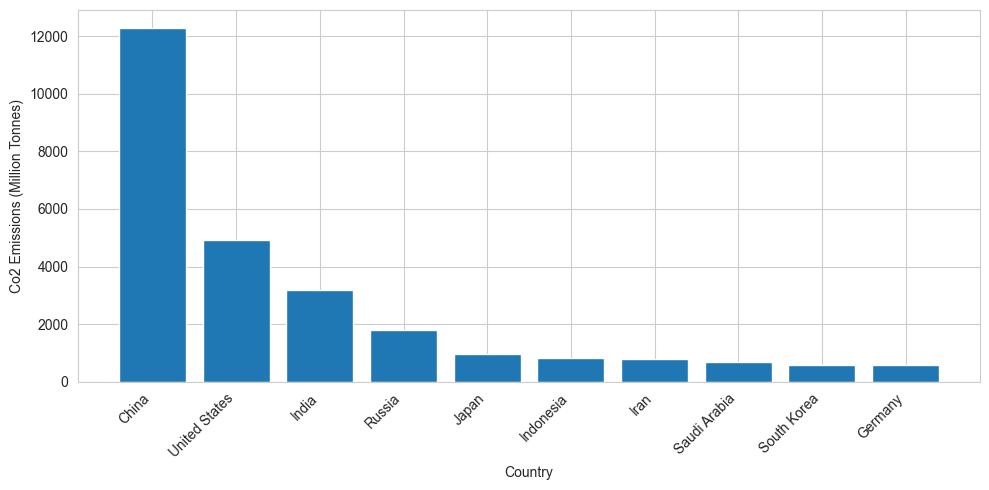

In [94]:
# Current Annual Emitters 
plt.figure(figsize=(10, 5))
plt.bar(top10_countries['country'], top10_countries['co2'])
plt.xlabel('Country')
plt.ylabel('Co2 Emissions (Million Tonnes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

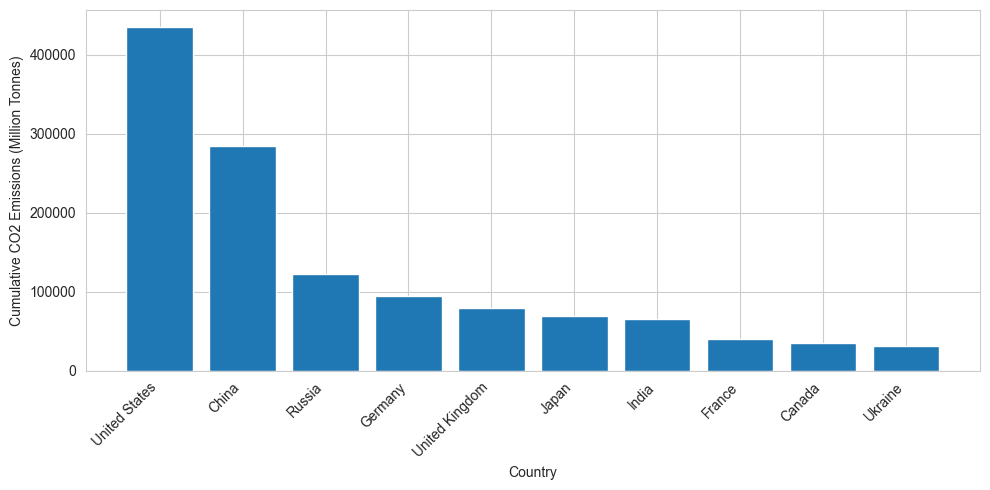

In [95]:
# Plotting Historical Cumulative Emitters
plt.figure(figsize=(10, 5)) 
plt.bar(top10_cumulative['country'], top10_cumulative['cumulative_co2'])
plt.xlabel('Country')
plt.ylabel('Cumulative CO2 Emissions (Million Tonnes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [99]:
# Identify the top 10 countries by cumulative CO2 emissions in the latest year
current_set = set(top10_countries['country'])
cumulative_set = set(top10_cumulative['country'])
common_countries = current_set.intersection(cumulative_set)
only_current = (current_set - cumulative_set)
only_cumulative = (cumulative_set - current_set)
only_current, only_cumulative, common_countries

({'Indonesia', 'Iran', 'Saudi Arabia', 'South Korea'},
 {'Canada', 'France', 'Ukraine', 'United Kingdom'},
 {'China', 'Germany', 'India', 'Japan', 'Russia', 'United States'})

## Interpretation
The comparison between current and cumulative emissions rankings shows clear differences in emissions responsibility. Some countries, including Indonesia, Iran, Saudi Arabia, and South Korea, appear among the top emitters today but not historically. This suggests that their emissions growth is more recent and linked to modern industrial and economic expansion.

In contrast, countries such as the United Kingdom, France, Canada, and Ukraine rank highly in cumulative emissions but are not among the top current emitters. This reflects their earlier industrial development and long-term historical contributions to global emissions.

Several countries, including the United States, China, Russia, India, Japan, and Germany, appear in both rankings. This indicates that they have contributed significantly to emissions both historically and in the present day.

Overall, this comparison support the hypothesis that historical cumulative emissions differ from current annual emissions rankings

##  Conclusion
## Exploratory Data Analysis Conclusion

The exploratory analysis examined global Co2 emissions from multiple perspectives, including total emissions, per-capita emissions, and cumulative historical contributions.
The results confirm that global emissions have increased significantly since 1990, despite short-term fluctuations. A small number of countries dominate current annual emissions, particularly large and industrialised economies.

However, when emissions are examined on a per-capita basis, the rankings change considerably. Several high-income and oil-producing countries record the highest emissions per person, while many developing nations with large populations have lower per-capita emissions. This highlights the difference between national totals and individual responsibility.

The comparison between current annual emissions and cumulative historical emissions further demonstrates that responsibility is not evenly distributed. Some countries have long-standing historical contributions due to early industrialisation, while others have emerged as major emitters more recently.

Overall, the analysis shows that emissions responsibility is complex and depends on how it is measured, whether by total output, per-capita impact, or historical accumulation. These findings provide a strong foundation for building a data-driven dashboard to support climate responsibility discussions.

## Exploratory Data Analysis Conclusion

The exploratory data analysis was conducted to support the development of the Global Co2 Emissions Responsibility Dashboard and to address the project’s business requirements of understanding emissions responsibility from multiple perspectives.

The analysis confirmed that global CO₂ emissions have increased significantly since 1990, highlighting the growing urgency of climate action. Current annual emissions rankings show that a small number of countries dominate global output, particularly large and industrialised economies.

However, when emissions were examined on a per-capita basis, the responsibility landscape changed. Several developed and high-income countries recorded the highest emissions per person, while many developing countries with large populations showed lower per-capita emissions. This demonstrates the importance of distinguishing between national totals and individual emissions impact.

Further analysis comparing current emissions with cumulative historical emissions revealed significant differences in responsibility over time. Some countries, particularly early industrialised nations, hold a larger share of historical emissions, while others have emerged as major emitters more recently.

These findings directly support the dashboard’s purpose of providing a balanced and transparent view of emissions responsibility. By combining total, per-capita, and cumulative perspectives, the dashboard enables policymakers, researchers, and the public to better understand fairness, accountability, and climate policy implications.

Overall, the EDA provides a strong analytical foundation for data-driven visualisations and insights presented within the dashboard.

## Data Export Preparation 
The cleaned and analysis-ready datasets were exported to support dashboard development. These datasets correspond to each validated hypothesis and will be used to create interactive visualisations.

In [100]:
# Dataset 1 -Global Emissions Trend (H1)
global_trend =(df_co2_emissions_clean.groupby('year', as_index=False)['co2'].sum())
global_trend.head()


,year,co2
0,1990,22184.273978
1,1991,22662.921003
2,1992,21966.606838
3,1993,22192.437121
4,1994,22389.768557


In [101]:
# Exporting the global trend data to a CSV file for future use
global_trend.to_csv('../DataSet/Exported/global_emissions_trend.csv', index=False)  

In [102]:
# Dataset 2 - Top 10 Current Emitters (H2A)
top10_current_export = df_latest_year.sort_values(by=['co2'], ascending=False)[['country', 'co2',  'population']]
top10_current_export

#Exporting the top 10 current emitters data to a CSV file for future use
top10_current_export.to_csv('../DataSet/Exported/top10_current_emitters.csv', index=False)

In [103]:
# Dataset 3 - Top 10 per capita emitters (H2B)
top10_per_capita_export = df_latest_year_clean.dropna(subset=['co2_per_capita']).sort_values(by='co2_per_capita', ascending=False).head(10)[['country', 'co2_per_capita', 'co2']]
top10_per_capita_export

,country,co2_per_capita,co2
5512,Qatar,41.271179,125.812256
3627,Kuwait,26.247530,129.518646
1084,Brunei,26.046202,12.052463
559,Bahrain,24.270082,39.003456
6842,Trinidad and Tobago,22.931944,34.576279
5897,Saudi Arabia,20.379194,692.133484
7122,United Arab Emirates,20.131075,221.988083
4812,New Caledonia,18.064400,5.286637
6107,Sint Maarten (Dutch part),16.546274,0.717645
5127,Oman,15.651107,82.661972


In [104]:
# Exporting the Top 10 per capita emitters data to a CSV file 
top10_per_capita_export.to_csv('../DataSet/Exported/top10_per_capita_emitters.csv', index=False)


In [105]:
# Dataset 4 - Top 10 Cumulative Emitters (H4)
top10_cumulative_export = df_latest_year.sort_values(by='cumulative_co2', ascending=False).head(10)[['country', 'cumulative_co2']]
top10_cumulative_export

,country,cumulative_co2
7192,United States,434866.56250
1469,China,285087.03130
5582,Russia,122808.22660
2682,Germany,95135.67969
7157,United Kingdom,80079.44531
3452,Japan,69612.28125
3172,India,66072.53125
2507,France,40047.56641
1294,Canada,35644.12891
7087,Ukraine,31236.49609


In [106]:
# Exporting To 10 Cumulative Emitters data to a CSV file
top10_cumulative_export.to_csv('../DataSet/Exported/top10_cumulative_emitters.csv', index=False)

In [107]:
# Exporting full cleaned dataset for future use
df_co2_emissions_clean.to_csv('../DataSet/Exported/co2_emissions_cleaned_full.csv', index=False)

### Export Summary
Four analysis-ready datasets were generated to support dashboard development:

- Global emissions trend dataset
- Top 10 current emitters dataset
- Top 10 per-capita emitters dataset
- Top 10 cumulative historical emitters dataset